In [64]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [65]:
data = pd.read_csv("../data/Telco-Customer-Churn.csv")
data.shape
print(f"Nous avons un dataset de {data.shape[0]} et de {data.shape[1]} colonnes")
data.head(10)

Nous avons un dataset de 7043 et de 21 colonnes


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [66]:
data.info()
print(f' les variables catégorielles:\n{data.select_dtypes(include="object").columns.to_list()}\n')
print(f' les variables numériques:\n{data.select_dtypes(include="number").columns.to_list()}')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


 ## REmarquons bien la feature TotalCharges qui contient des chiffres mais est considéré comme object
 Pourquoi cela arrive-t-il ?
Dans ces données, il y a exactement 11 clients qui viennent tout juste de souscrire à leur abonnement. Leur durée d'abonnement (tenure) est de 0 mois. Comme ils n'ont pas encore reçu de facture cumulée, la case TotalCharges n'a pas été remplie avec un 0, mais avec un simple espace vide (" ").

Quand Pandas importe le fichier, il scanne la colonne. Lorsqu'il tombe sur ces espaces vides, il n'arrive pas à les lire comme des nombres. Par sécurité, il décide que toute la colonne doit être traitée comme du texte (object).
 


In [67]:
data["TotalCharges"] = pd.to_numeric(data["TotalCharges"], errors='coerce')
# Afin de remplacer les champs vide par NAn et régler le problème

In [68]:
print(f' les variables numériques:\n{data.select_dtypes(include="number").columns.to_list()}')

 les variables numériques:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


## VALEURS MANQUANTES

In [69]:
missing = data.isnull().sum()
print(f" la quantité de valeurs manquantes par features est : \n {missing}")

 la quantité de valeurs manquantes par features est : 
 customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


## VALEURS DUPLIQUEES

In [33]:
duplic = data.duplicated().sum()
print(f"la somme des  doublons de notre dataset est: \n {duplic}") 

la somme des  doublons de notre dataset est: 
 0


## RESUME STATISTIQE DU DATASET

In [34]:
data.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [35]:
data.describe(include="object")

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,3186-AJIEK,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,20.2,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


## Analyse Univariée

 ### Avant de continuer , nous devons transformer notre target "Churn" pour remplacer les valeurs textuelles par des chiffres 0 et 1 a la place de Yes ou No

In [71]:
data["Churn"] = (data["Churn"] == "Yes").astype(int)

In [72]:
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


## Distribution de la variable cible " Churn "

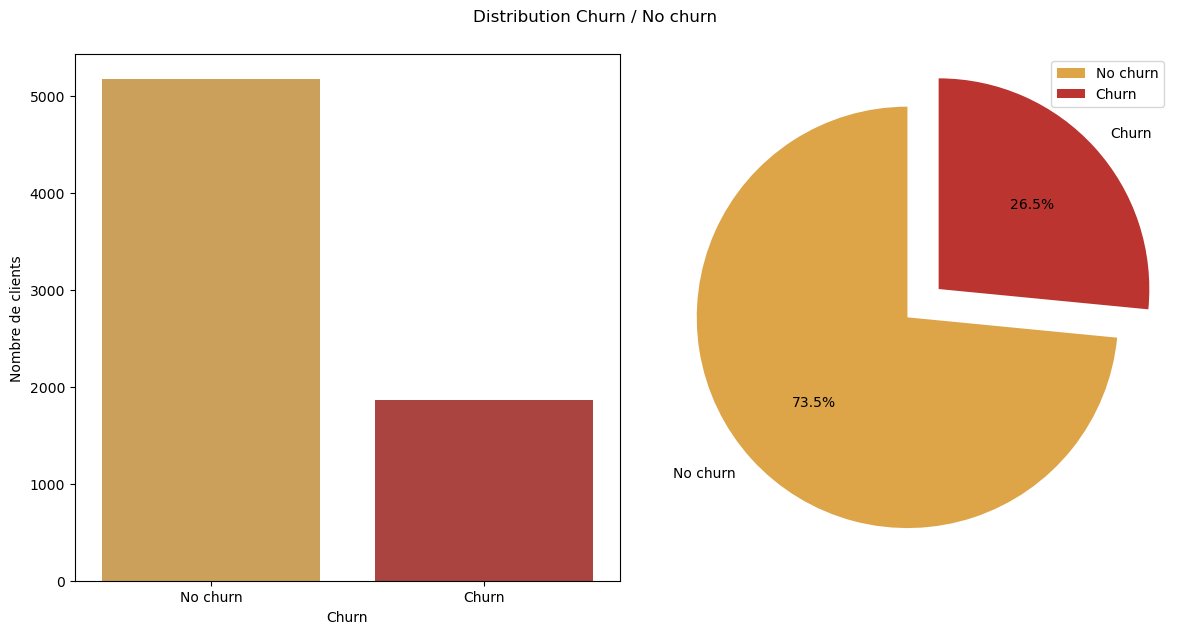

In [73]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# Graphique en barres (Countplot)
sns.countplot(data=data, x="Churn", palette=["#DDA448", "#BB342F"], hue="Churn" ,legend=False, ax=ax[0])
ax[0].set_xticks([0, 1]) 
ax[0].set_xticklabels(["No churn", "Churn"]) 
ax[0].set_ylabel("Nombre de clients")

# Graphique circulaire (Pie chart)
data["Churn"].value_counts().plot.pie(
    startangle=90, 
    labels=["No churn", "Churn"], 
    explode=(0, 0.2), 
    autopct='%1.1f%%', 
    colors=["#DDA448", "#BB342F"], 
    ax=ax[1]
)
ax[1].set_ylabel("") # Masque l'étiquette "count" sur le côté pour plus d'esthétisme
ax[1].legend()

plt.tight_layout()
plt.suptitle("Distribution Churn / No churn", y=1.05) # y=1.05 évite que le titre ne touche les graphiques
plt.show()

## Analyse des variables catégorielles 

In [98]:
cat_feature = data.select_dtypes(include="object").columns.to_list()
cat_feature = cat_feature[1:]
cat_feature.append('SeniorCitizen')
cat_feature

['gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'SeniorCitizen']

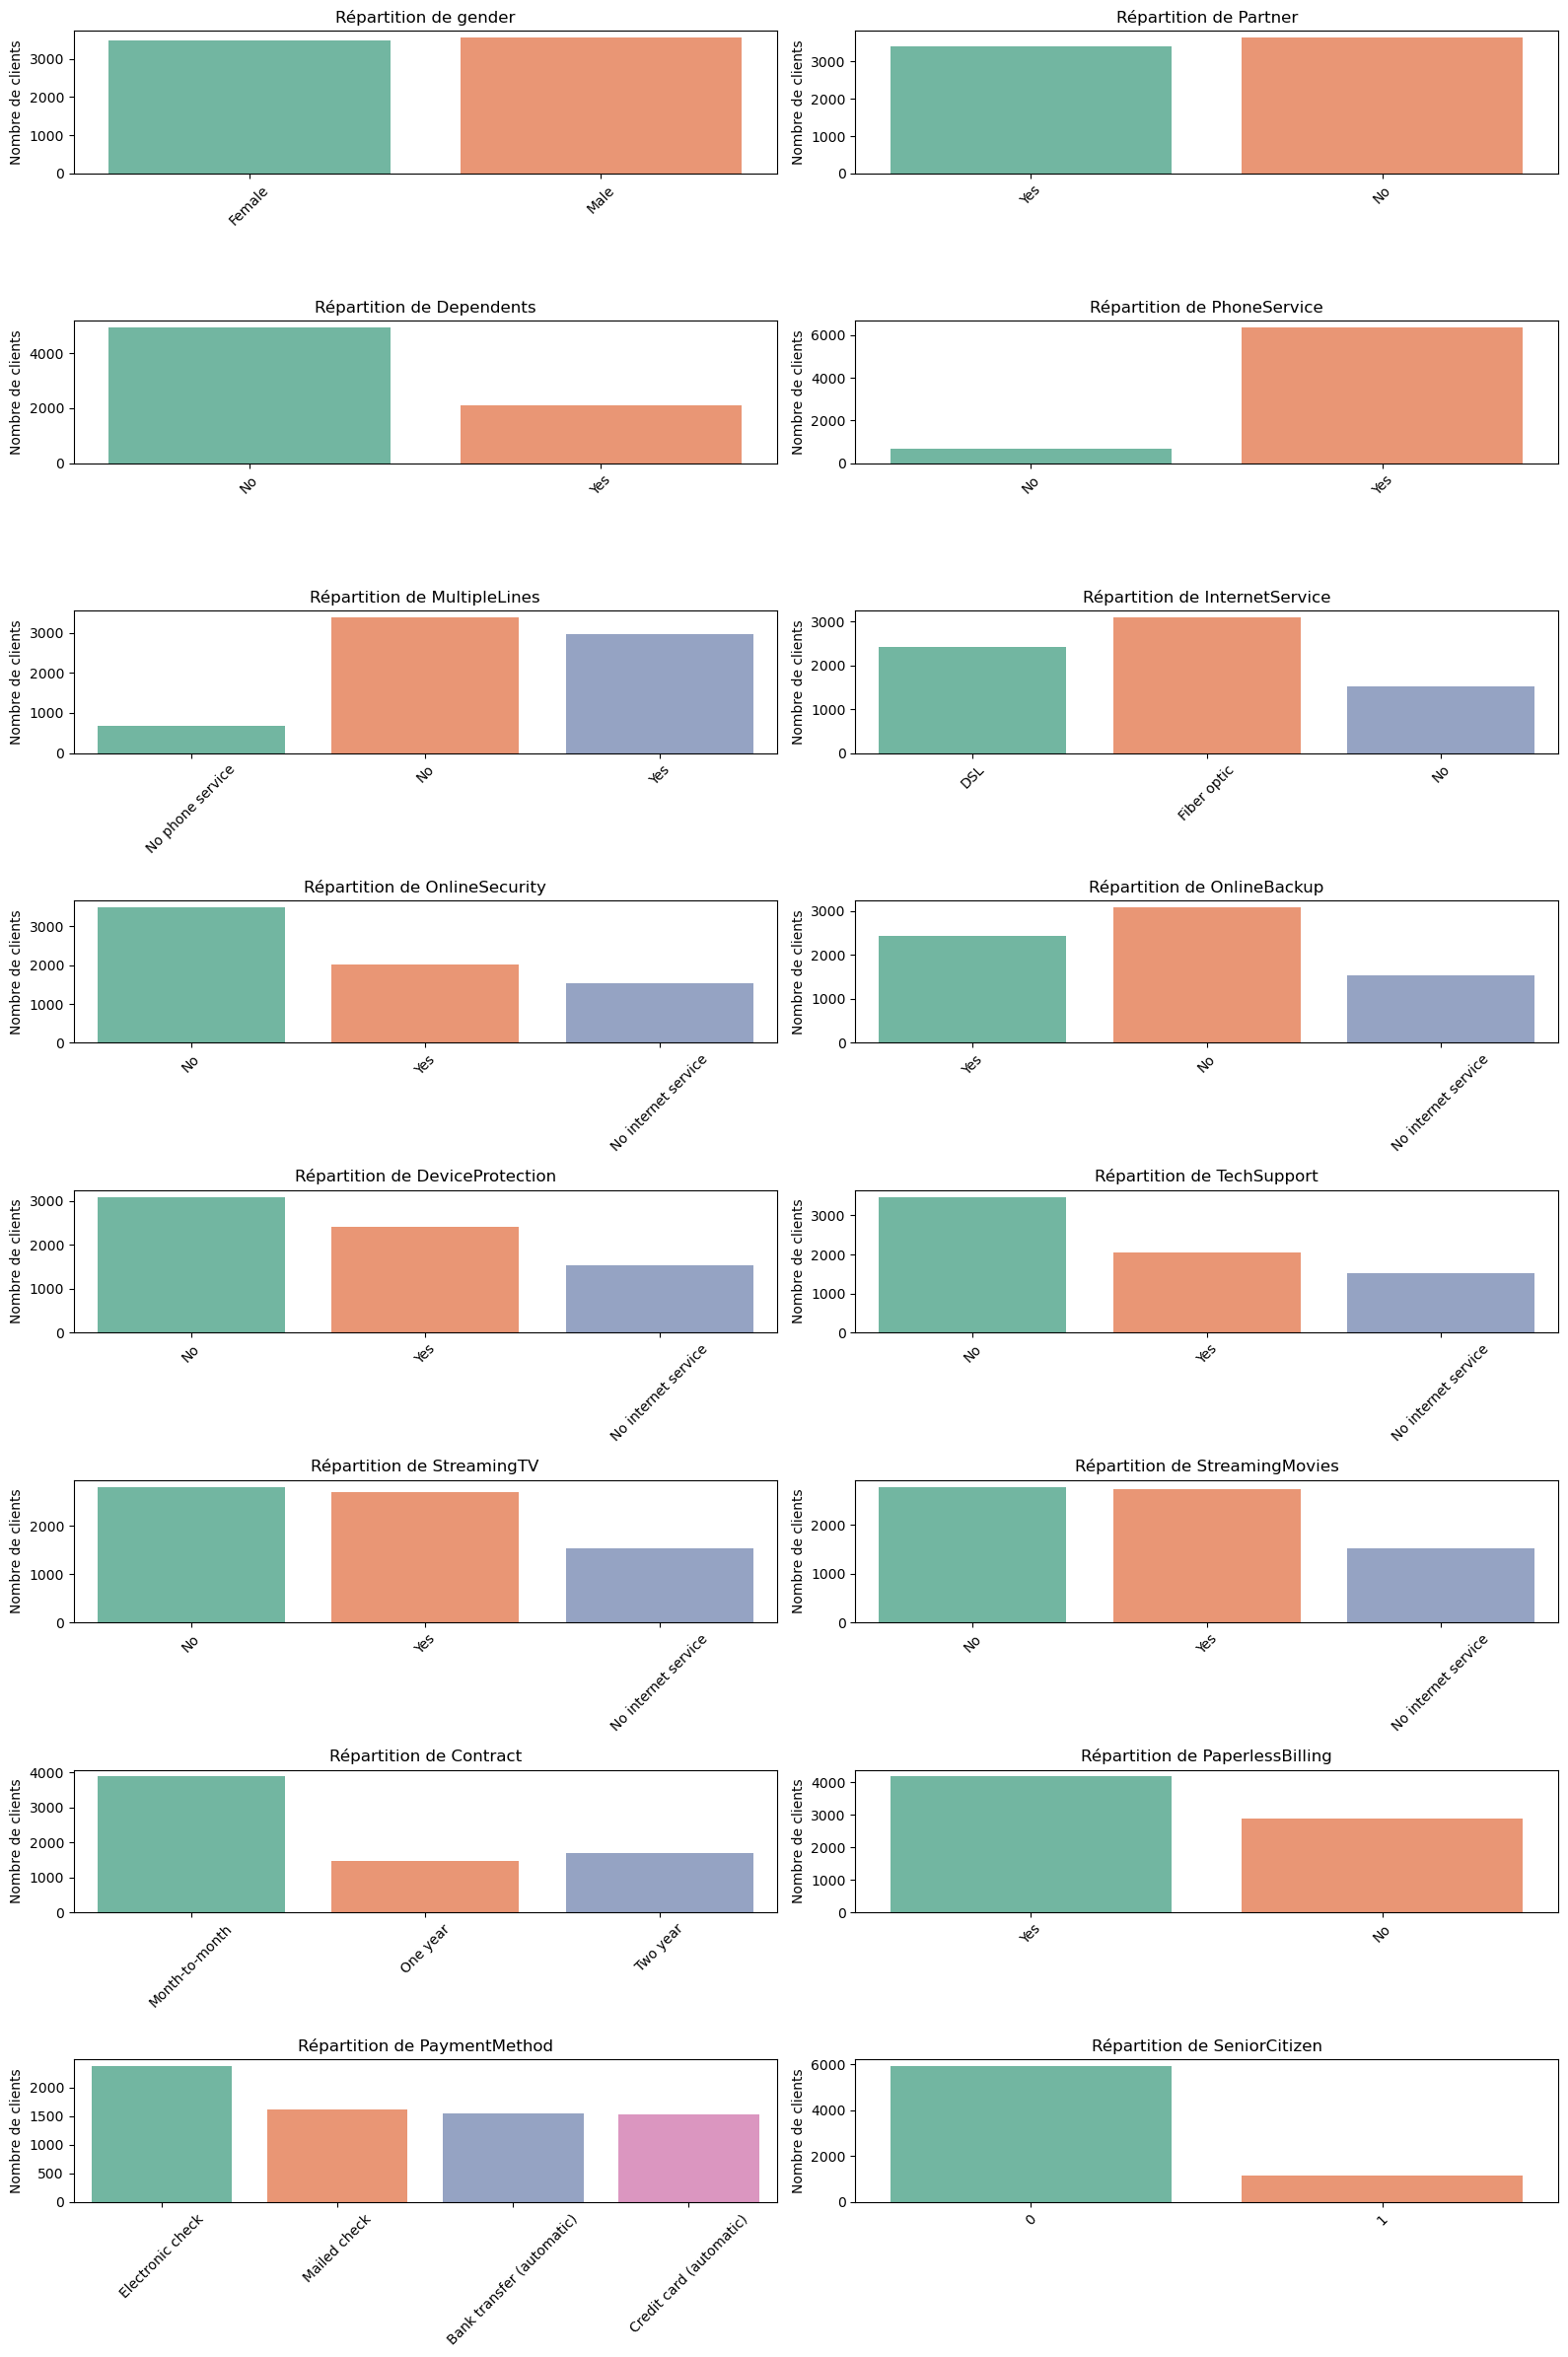

In [99]:
# 6 lignes et 3 colonnes pour accueillir tes 18 variables
fig, ax = plt.subplots(8, 2, figsize=(16, 24)) 
ax = ax.flatten()

for index, val in enumerate(cat_feature):
    sns.countplot(data=data, x=val, hue=val, palette="Set2", ax=ax[index], legend=False)
    ax[index].set_title(f"Répartition de {val}")
    ax[index].set_ylabel("Nombre de clients") # Ajustement du texte
    ax[index].set_xlabel("") 
    ax[index].tick_params(axis='x', rotation=45) 

plt.tight_layout()
plt.show()

In [100]:
num_feature = data.select_dtypes(include="number").columns.to_list()
num_feature = num_feature[1:-1]
num_feature

['tenure', 'MonthlyCharges', 'TotalCharges']

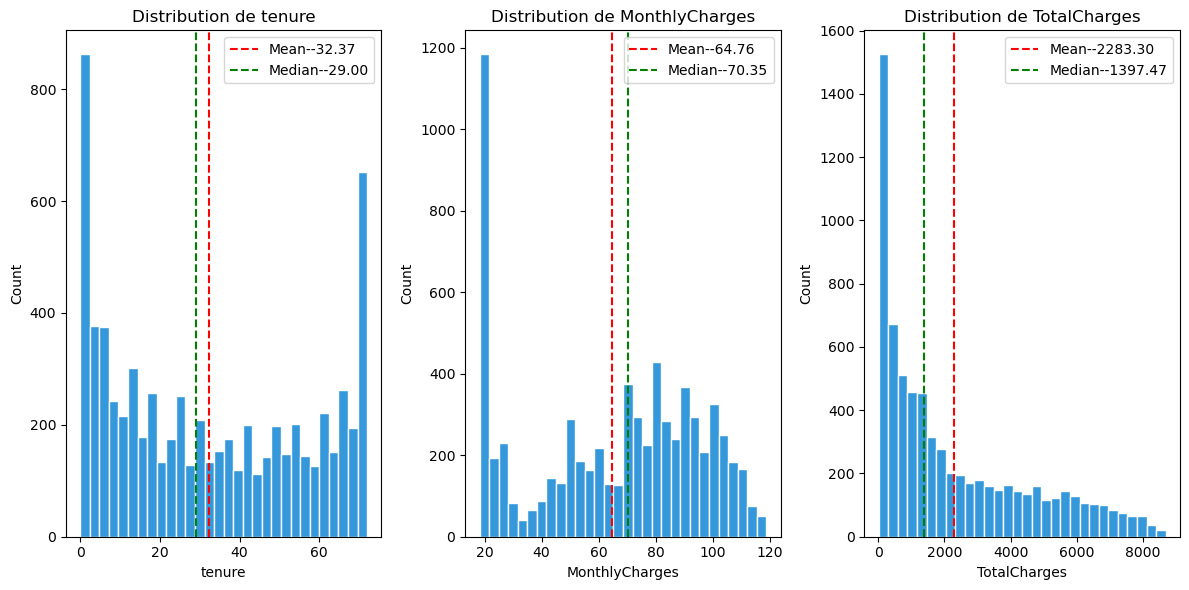

In [101]:
fig, ax = plt.subplots(1,3, figsize=(12,6))
ax = ax.flatten()

for i , val in enumerate(num_feature):
    ax[i].hist(data[val].dropna() , bins=30, color="#3498db" , edgecolor="white")
    ax[i].axvline(data[val].mean(), linestyle="--" , color = "red", label = f"Mean--{data[val].mean():.2f}")
    ax[i].axvline(data[val].median(), linestyle="--", color="green", label= f"Median--{data[val].median():.2f}")
    ax[i].set_title(f"Distribution de {val}")
    ax[i].set_xlabel(f"{val}")
    ax[i].set_ylabel("Count")
    ax[i].legend()


plt.tight_layout()
plt.show()

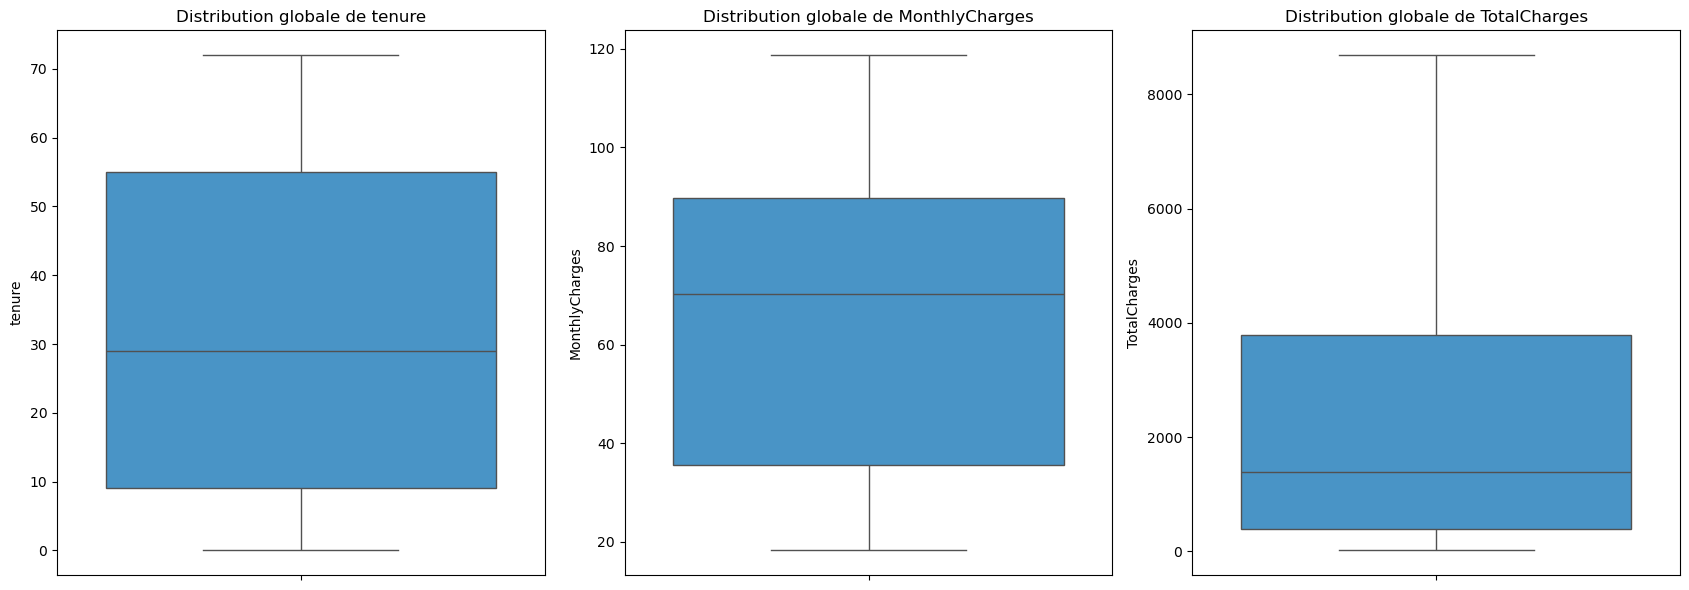

In [102]:
fig, ax = plt.subplots(1, 3, figsize=(17, 6))
ax = ax.flatten()


for i, col in enumerate(num_feature):
    # On supprime x="stroke" et hue="stroke" pour avoir la distribution globale
    sns.boxplot(
        data=data, 
        y=col, 
        ax=ax[i], 
        color="#3498db" # Une seule couleur pour l'ensemble du jeu de données
    )
    
    ax[i].set_title(f"Distribution globale de {col}")
    ax[i].set_ylabel(col)

plt.tight_layout()
plt.show()

## ANALYSE BIVARIEE

In [ ]:
## Feature Numeric & Target 

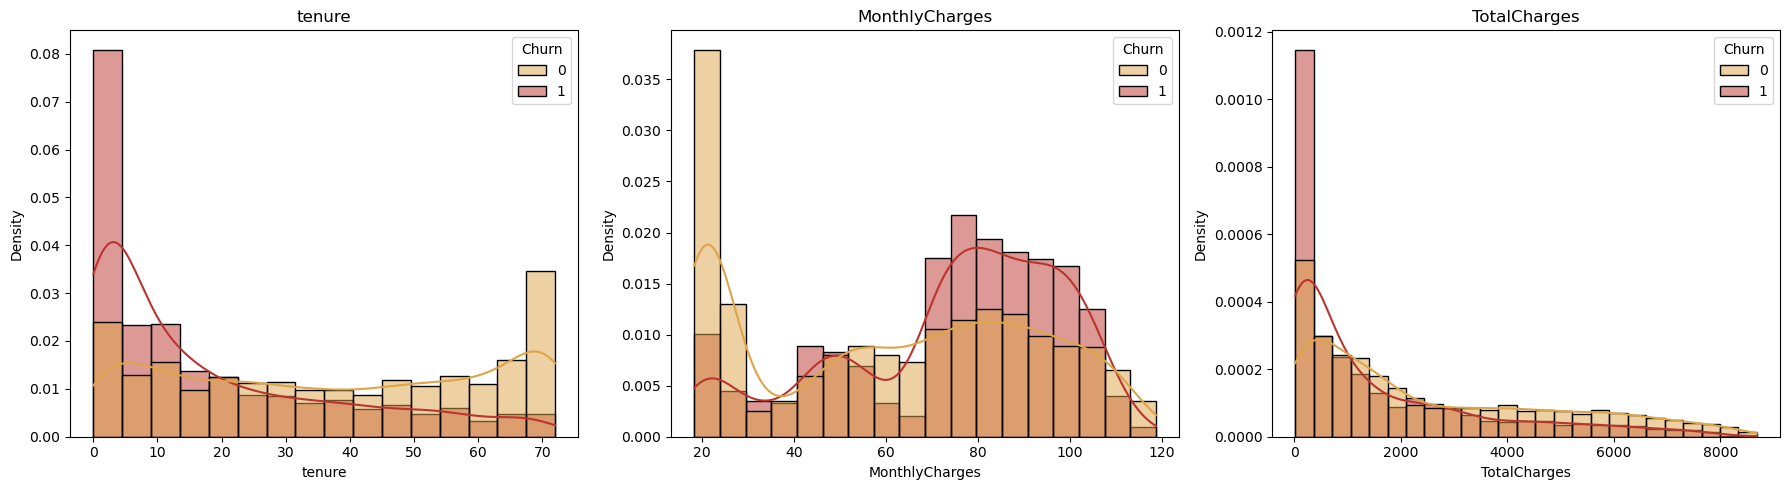

In [104]:

fig, ax = plt.subplots(1, len(num_feature), figsize=(18, 5))

for index, val in enumerate(num_feature):
    sns.histplot(
        data=data, 
        x=val, 
        hue="Churn",  
        kde=True,          
        stat="density",     
        common_norm=False,  
        palette=["#DDA448", "#BB342F"],
        alpha=0.5,          
        ax=ax[index]
    )
    
    ax[index].set_title(val)

plt.tight_layout()
plt.show()

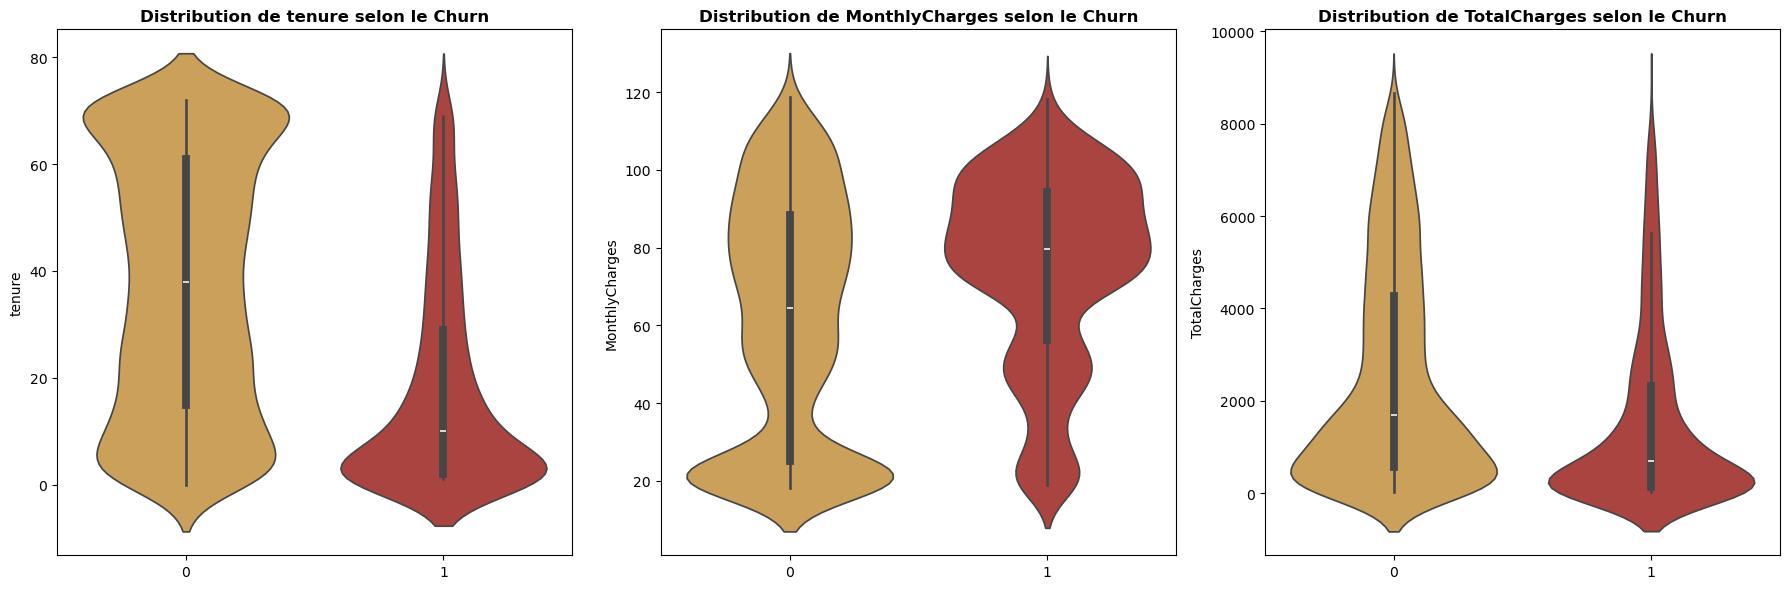

In [110]:


fig, ax = plt.subplots(1, 3, figsize=(18, 6))

for index, val in enumerate(num_feature):
    
    sns.violinplot(
        data=data, 
        x="Churn", 
        y=val, 
        hue="Churn", 
        legend=False,
        palette=["#DDA448", "#BB342F"], 
        ax=ax[index]
    )
    
    ax[index].set_title(f"Distribution de {val} selon le Churn", fontsize=12, fontweight='bold')
    ax[index].set_xlabel("")
    ax[index].set_ylabel(val)

plt.tight_layout()
plt.show()

In [ ]:
## Feature Categorielle & Target

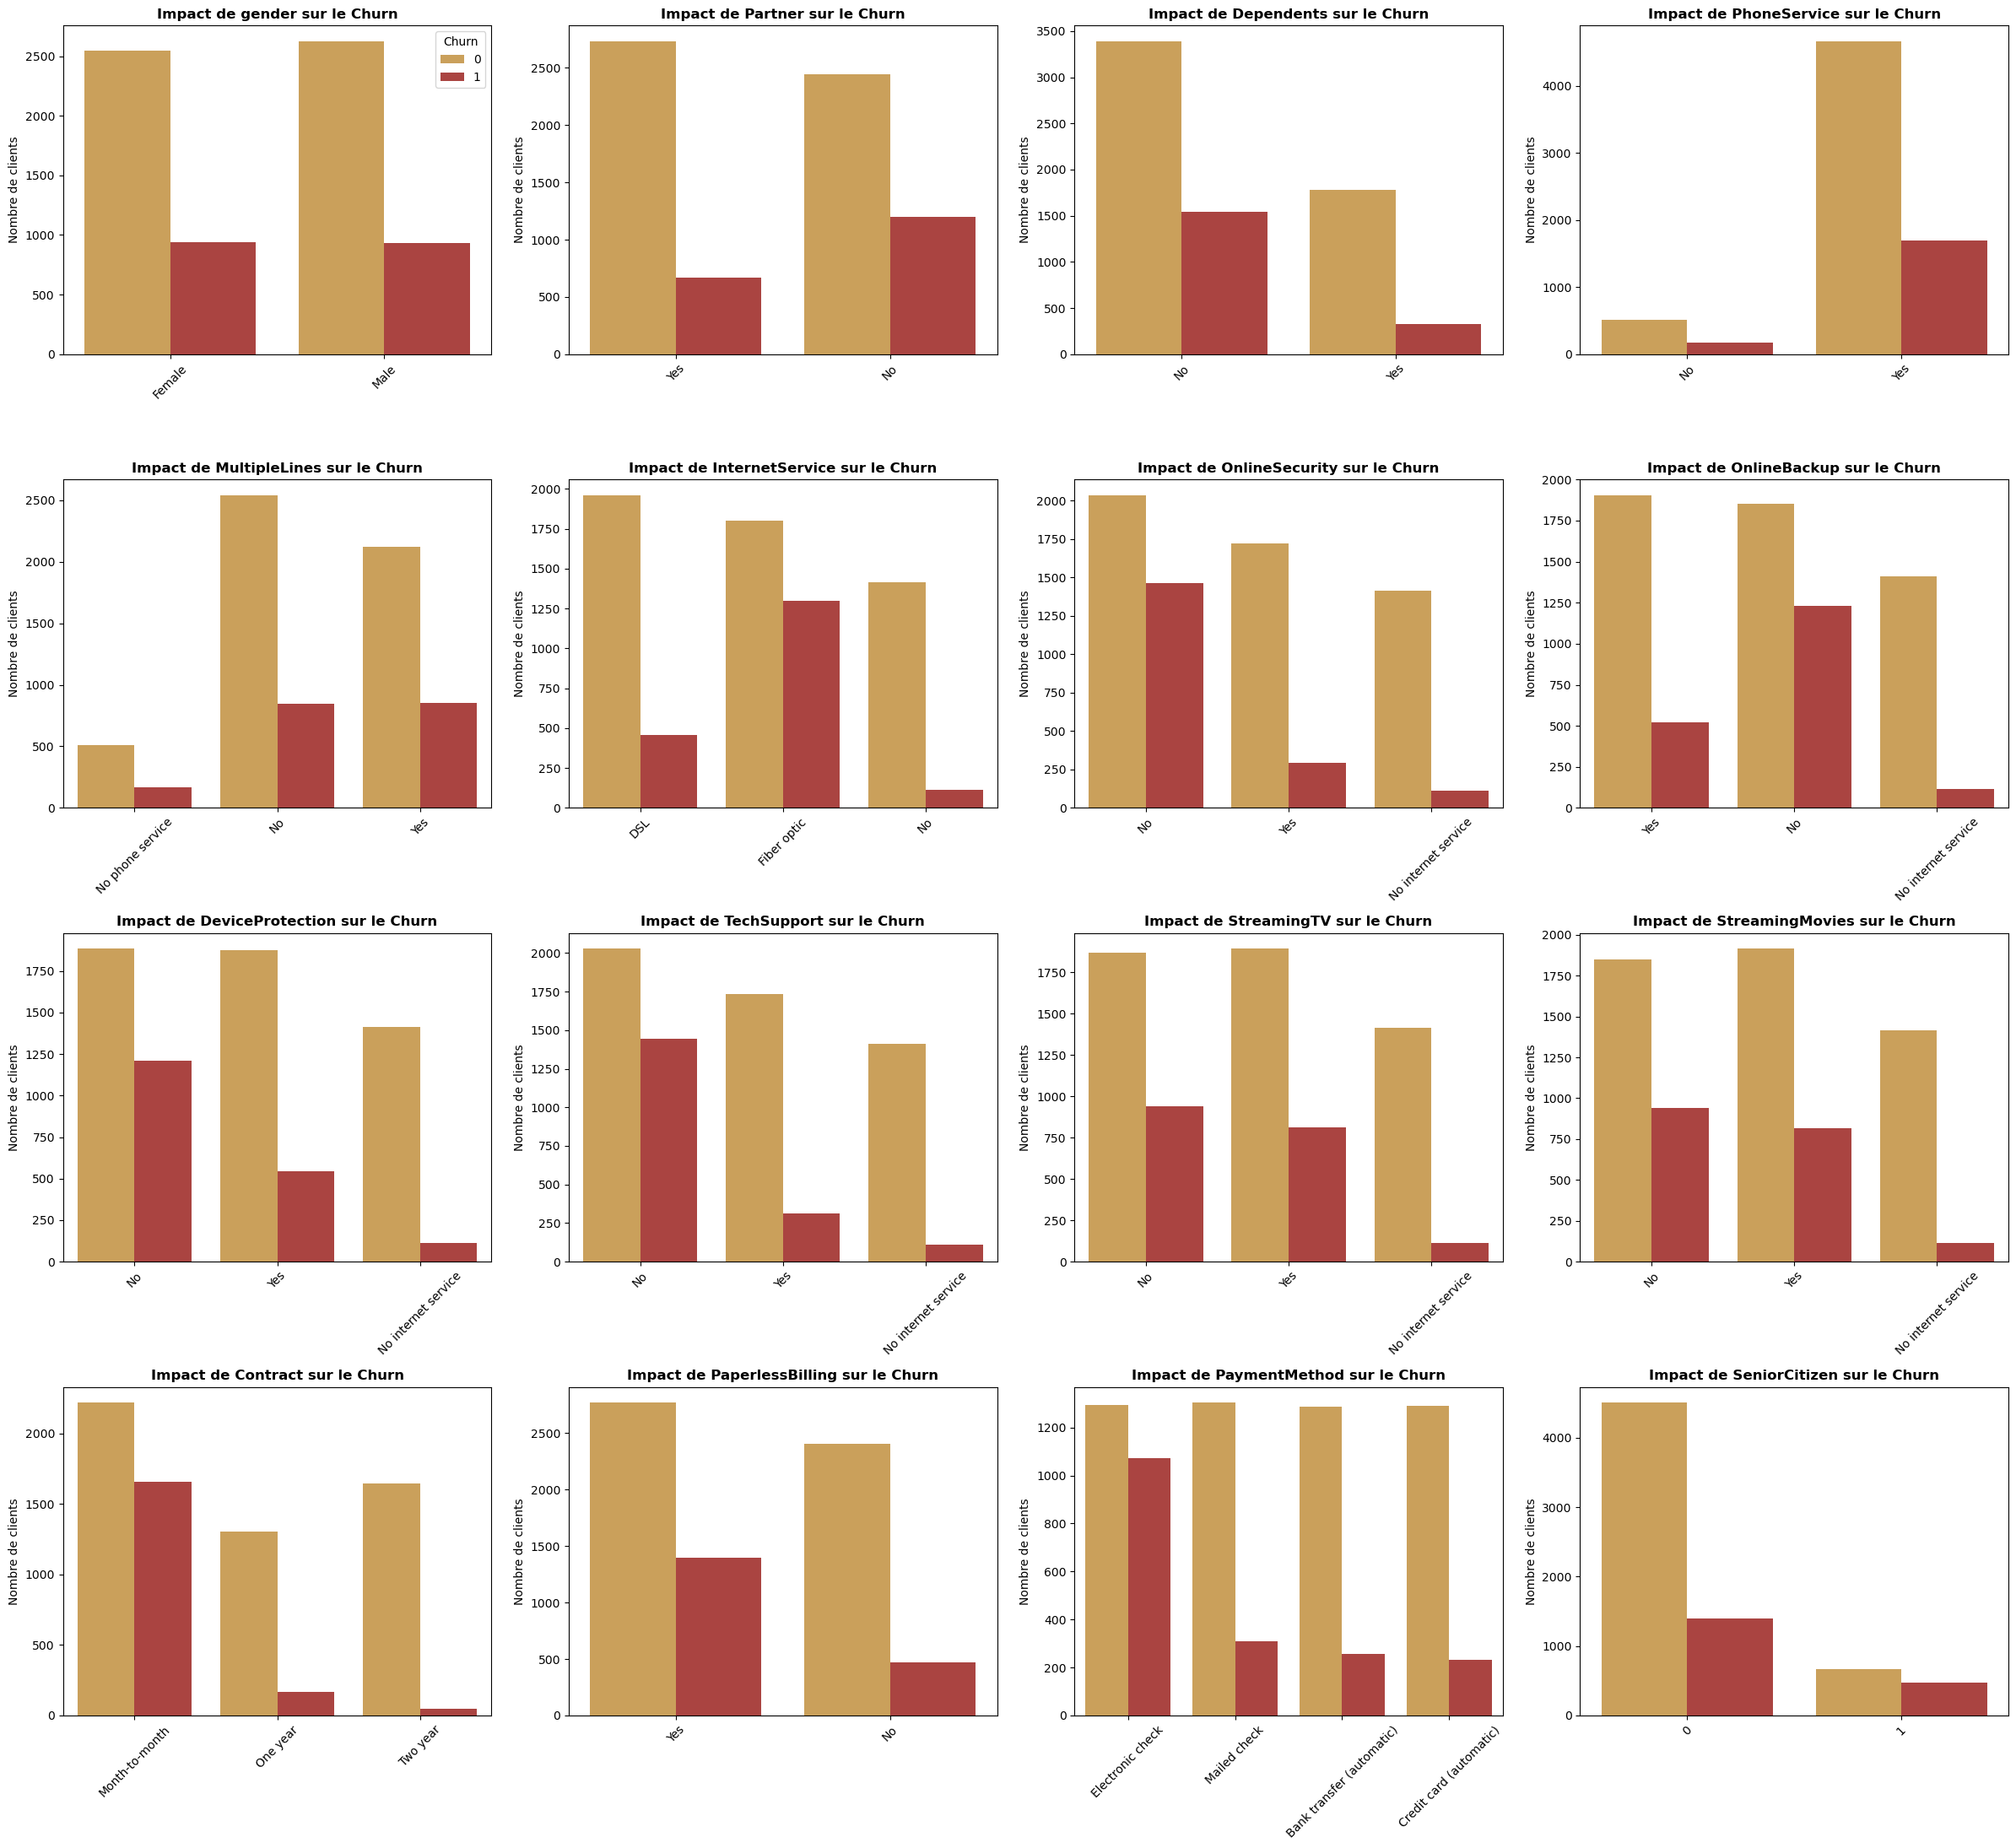

In [111]:


fig, ax = plt.subplots(4, 4, figsize=(24, 22))
ax = ax.flatten()

for index, val in enumerate(cat_feature):
    
    sns.countplot(
        data=data, 
        x=val, 
        hue="Churn", 
        palette=["#DDA448", "#BB342F"], # Or = No Churn, Rouge = Churn
        ax=ax[index]
    )
    
    
    ax[index].set_title(f"Impact de {val} sur le Churn", fontsize=12, fontweight='bold')
    ax[index].set_ylabel("Nombre de clients")
    ax[index].set_xlabel("")
    ax[index].tick_params(axis='x', rotation=45)
    
    
    if index != 0:
        ax[index].get_legend().remove()

plt.tight_layout()
plt.show()

## HEATMAPS

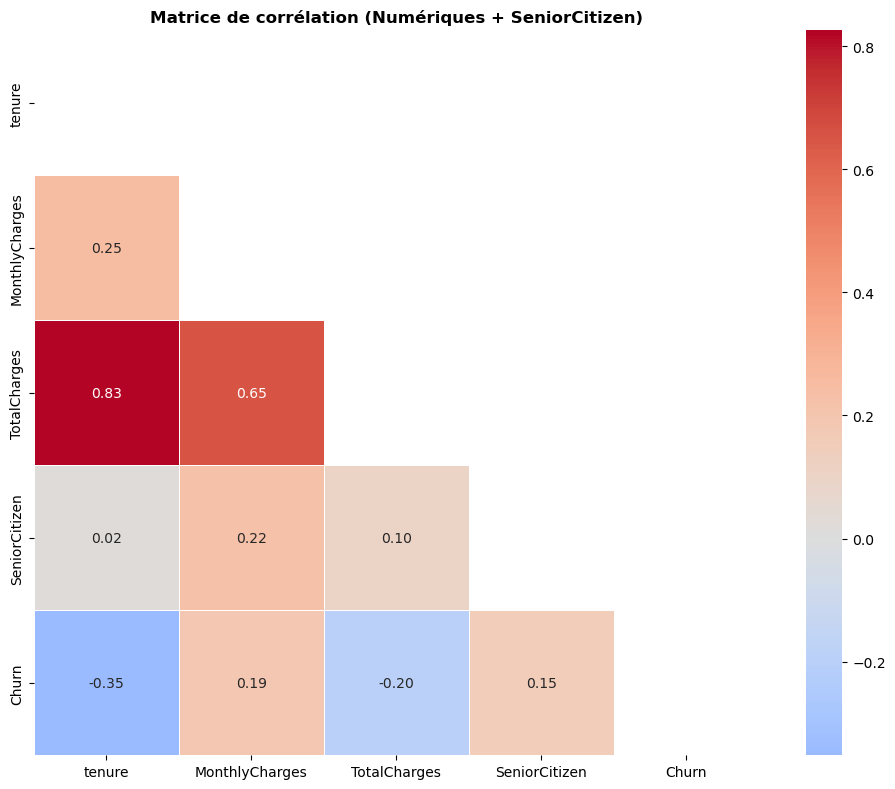

In [112]:

num_vars = ["tenure", "MonthlyCharges", "TotalCharges", "SeniorCitizen", "Churn"]

plt.figure(figsize=(10, 8))
corr = data[num_vars].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr, 
    mask=mask, 
    annot=True, 
    fmt=".2f", 
    cmap="coolwarm", 
    center=0, 
    square=True, 
    linewidths=0.5
)

plt.title("Matrice de corrélation ", fontweight='bold')
plt.tight_layout()
plt.show()

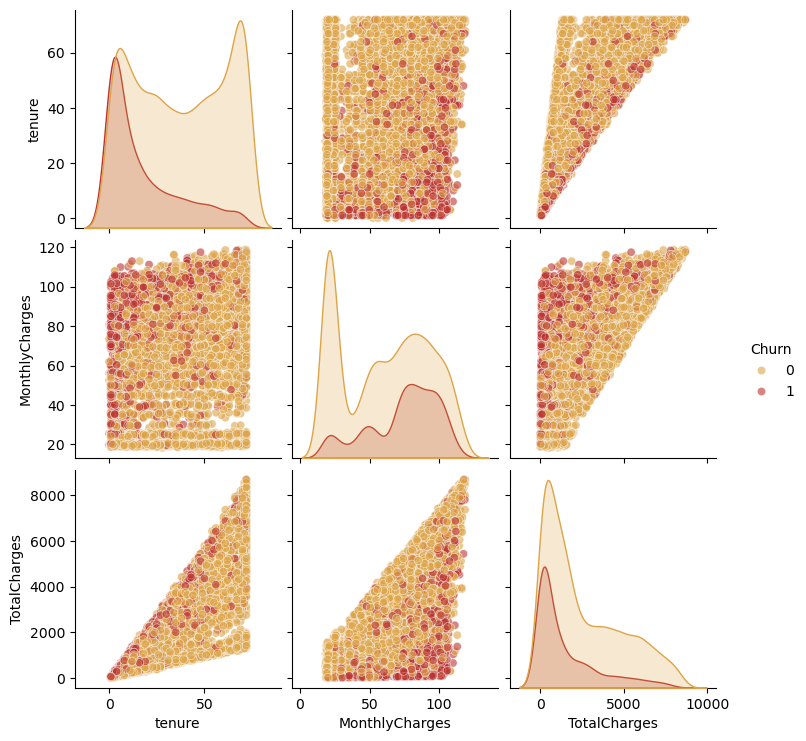

In [117]:


sns.pairplot(
    data[['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']], 
    hue="Churn", 
    palette=["#DDA448", "#BB342F"],
    plot_kws={'alpha': 0.6}
)
plt.show()